# Full Subject Correlations (Event-Aligned)

This version aligns subjects by **event index** (not raw sample index) so shorter subjects like `rr` can still be used.


## Mathematical Setup (Full Holdout Subject)

Let $h$ be the holdout subject (e.g., $aa$ or $rr$), and let $s$ index training subjects ($s \neq h$).

### 1) Event-aligned subject data
For each subject $s$, build event-level features:

$$
X_s \in \mathbb{R}^{T \times n_s}
$$

where $T$ is the shared event-prefix length and $n_s$ is the number of electrodes for subject $s$.

### 2) Subject correlation matrices (training only)
For each training subject:

$$
C_s = \mathrm{corr}(X_s), \quad C_s \in \mathbb{R}^{n_s \times n_s}
$$

### 3) Spatial interpolation into pooled space
Let pooled coordinates have size $L$. For each training subject, build Gaussian distance weights:

$$
W_s \in \mathbb{R}^{L \times n_s}
$$

Interpolate each subject correlation into pooled space in Fisher-$z$ domain:

$$
Z_s = \operatorname{atanh}(C_s)
$$

$$
\hat{Z}_s = \frac{W_s Z_s W_s^\top}{W_s \mathbf{1}\mathbf{1}^\top W_s^\top}
$$

$$
\hat{C}_s = \tanh(\hat{Z}_s)
$$

### 4) Group pooled correlation matrix (training only)
Average only over training subjects:

$$
\hat{K} \equiv \hat{K}_{\text{no-leak}} = \tanh\left( \frac{1}{|\mathcal{S}_{\text{train}}|} \sum_{s \in \mathcal{S}_{\text{train}}} \operatorname{atanh}(\hat{C}_s) \right)
$$

This $\hat{K}$ is the pooled cross-subject correlation matrix used for decoding.

### 5) Build pooled predictor signals from training subjects
Row-normalize $W_s$ to $\widetilde{W}_s$, then project each training subject into pooled space:

$$
Y_{\text{pool},s} = X_s \widetilde{W}_s^\top, \quad Y_{\text{pool},s} \in \mathbb{R}^{T \times L}
$$

Average across training subjects to get pooled predictors:

$$
Y_{\alpha,\text{all}} \in \mathbb{R}^{T \times L}
$$

Then select predictor pooled indices $\alpha$:

$$
Y_\alpha = Y_{\alpha,\text{all}}[:,\alpha]
$$

### 6) Holdout targets and decoder
Holdout target matrix:

$$
Y_\beta^{\text{true}} = X_h
$$

Correlation blocks from $\hat{K}$:

$$
\hat{K}_{\alpha\alpha} = \hat{K}[\alpha,\alpha], \qquad \hat{K}_{\beta\alpha} = \hat{K}[\beta,\alpha]
$$

Decoder (ridge/PSD-regularized inverse):

$$
D = \hat{K}_{\beta\alpha} \left(\hat{K}_{\alpha\alpha} + \lambda I\right)^{-1}
$$

Prediction:

$$
Y_\beta^{\text{pred}} = \left(DY_\alpha^\top\right)^\top
$$

---

## Exact Difference vs Electrode\_Correlations.ipynb

- This notebook: full holdout-subject decode ($Y_\beta^{\text{true}}$ is from the held-out subject; training excludes that subject).
- Electrode\_Correlations.ipynb: within-subject electrode holdout (observed and held-out channels come from the same subject recording).
- Decoder form is the same:

$$
D = \hat{K}_{\beta\alpha} \left(\hat{K}_{\alpha\alpha} + \lambda I\right)^{-1}
$$

(with regularization in practice), but the source of $Y_\alpha$ and train/test split are different.





## Step 0.1 - Imports and Settings


In [484]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat
from scipy.stats import pearsonr

# Main paths
project_root = Path('/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project')
preprocessed_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
raw_data_root = Path('/Users/rustin/Documents/Big Data 567/faces_basic/data')

# Main experiment switches
holdout_pid = 'rr'                 
include_rr_in_training = False      # since rr has different length than others ... if holdout is not rr, include rr as training subject
coord_round_decimals = 3
lambda_width = 20
ridge = 1

print('holdout_pid =', holdout_pid)
print('include_rr_in_training =', include_rr_in_training)
print('lambda_width =', lambda_width)
print('ridge =', ridge)




holdout_pid = rr
include_rr_in_training = False
lambda_width = 20
ridge = 1


## Step 0.2 - Helper Functions


In [485]:
def fisher_z(x):
    x = np.asarray(x, dtype=np.float32)
    x = np.clip(x, -0.999999, 0.999999)
    return np.arctanh(x)


def inverse_fisher_z(z):
    return np.tanh(z)


def zscore_cols(x, eps=1e-6):
    x = np.asarray(x, dtype=np.float32)
    mu = x.mean(axis=0, keepdims=True)
    sd = x.std(axis=0, keepdims=True)
    sd[sd < eps] = 1.0
    return (x - mu) / sd


def safe_corr(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    if x.std() < 1e-8 or y.std() < 1e-8:
        return np.nan
    r = pearsonr(x, y).statistic
    return float(r) if np.isfinite(r) else np.nan


def coord_key(coord, decimals=3):
    return tuple(np.round(np.asarray(coord, dtype=np.float32), decimals).tolist())


def collapse_event_order(stim):
    stim = np.asarray(stim).ravel()
    nz = stim[stim != 0]
    if nz.size == 0:
        return np.array([], dtype=np.int32)
    keep = np.r_[True, nz[1:] != nz[:-1]]
    return nz[keep].astype(np.int32)


def event_means_from_preprocessed_and_stim(ecog, stim_raw):
    """
    ecog: preprocessed ecog with time rows corresponding to stim_raw[stim_raw != 0]
    returns:
      event_means: (n_events, n_channels)
      event_ids:   (n_events,)
    """
    stim_raw = np.asarray(stim_raw).ravel()
    stim_nz = stim_raw[stim_raw != 0]

    if stim_nz.shape[0] != ecog.shape[0]:
        raise ValueError(f'stim_nz length ({stim_nz.shape[0]}) != ecog rows ({ecog.shape[0]})')

    # event boundaries in non-zero stim stream
    starts = np.r_[0, 1 + np.where(stim_nz[1:] != stim_nz[:-1])[0]]
    ends = np.r_[starts[1:], stim_nz.shape[0]]

    event_ids = stim_nz[starts].astype(np.int32)
    event_means = np.zeros((starts.shape[0], ecog.shape[1]), dtype=np.float32)

    for i, (a, b) in enumerate(zip(starts, ends)):
        event_means[i] = ecog[a:b].mean(axis=0)

    return event_means, event_ids

print('Helper functions ready.')


Helper functions ready.


## Step 1.1 - Load Preprocessed Subject Files


In [486]:
assert preprocessed_dir.exists(), f'Missing directory: {preprocessed_dir}'

subject_files = sorted(preprocessed_dir.glob('*_preprocessed.npz'))
assert subject_files, f'No *_preprocessed.npz files found in {preprocessed_dir}'

pre = {}
for path in subject_files:
    pack = np.load(path, allow_pickle=True)
    pid = str(pack['subject_id'].item()) if 'subject_id' in pack.files else path.stem.replace('_preprocessed', '')
    pre[pid] = {
        'path': path,
        'locs': np.asarray(pack['locs_mni_mm'], dtype=np.float32),
        'ecog': np.asarray(pack['ecog'], dtype=np.float32),
        'sample_rate_hz': int(np.asarray(pack['sample_rate_hz']).squeeze()),
    }

print('Loaded preprocessed subjects:', sorted(pre.keys()))


Loaded preprocessed subjects: ['aa', 'ap', 'ca', 'de', 'fp', 'ha', 'ja', 'jt', 'mv', 'rn', 'rr', 'wc', 'zt']


## Step 1.2 - Load Raw Stim and Keep Common Subjects


In [487]:
raw_stim = {}
for pid in sorted(pre.keys()):
    mat_path = raw_data_root / pid / f'{pid}_faceshouses.mat'
    if not mat_path.exists():
        continue
    mat = loadmat(mat_path, squeeze_me=True)
    if 'stim' not in mat:
        continue
    raw_stim[pid] = np.asarray(mat['stim']).ravel()

common_pids = sorted(set(pre.keys()) & set(raw_stim.keys()))
assert holdout_pid in common_pids, f'{holdout_pid} not available in both preprocessed and raw stim sets'

print('Subjects with both preprocessed ecog and raw stim:', common_pids)
print('Count:', len(common_pids))


Subjects with both preprocessed ecog and raw stim: ['aa', 'ap', 'ca', 'de', 'fp', 'ha', 'ja', 'jt', 'mv', 'rn', 'rr', 'wc', 'zt']
Count: 13


## Step 1.3 - Build Event-Level Features Per Subject


In [488]:
subject_event = {}
for pid in common_pids:
    ecog = pre[pid]['ecog']
    stim = raw_stim[pid]

    event_means, event_ids = event_means_from_preprocessed_and_stim(ecog, stim)
    subject_event[pid] = {
        'event_means': event_means,
        'event_ids': event_ids,
        'n_events': int(event_ids.shape[0]),
        'n_channels': int(event_means.shape[1]),
    }

print('Event feature summary:')
for pid in common_pids:
    s = subject_event[pid]
    print(f"[{pid}] n_events={s['n_events']} | event_means={s['event_means'].shape}")


Event feature summary:
[aa] n_events=601 | event_means=(601, 41)
[ap] n_events=601 | event_means=(601, 40)
[ca] n_events=601 | event_means=(601, 49)
[de] n_events=601 | event_means=(601, 31)
[fp] n_events=601 | event_means=(601, 11)
[ha] n_events=601 | event_means=(601, 39)
[ja] n_events=601 | event_means=(601, 37)
[jt] n_events=601 | event_means=(601, 96)
[mv] n_events=601 | event_means=(601, 19)
[rn] n_events=601 | event_means=(601, 41)
[rr] n_events=401 | event_means=(401, 40)
[wc] n_events=601 | event_means=(601, 38)
[zt] n_events=601 | event_means=(601, 58)


## Step 1.4 - Event-Order Check (Prefix-Compatible)


In [489]:
ref_pid = holdout_pid
ref_seq = subject_event[ref_pid]['event_ids']

print('Reference subject:', ref_pid)
print('Reference n_events:', len(ref_seq))
print('Reference first 30 events:', ref_seq[:30].astype(int).tolist())
print('')

for pid in common_pids:
    seq = subject_event[pid]['event_ids']
    m = min(len(seq), len(ref_seq))
    same_prefix = np.array_equal(seq[:m], ref_seq[:m])
    same_full = np.array_equal(seq, ref_seq)
    print(f'  {pid}: events={len(seq)} | same_full={same_full} | same_prefix={same_prefix}')

# hard stop if any subject breaks prefix order with reference
for pid in common_pids:
    seq = subject_event[pid]['event_ids']
    m = min(len(seq), len(ref_seq))
    if not np.array_equal(seq[:m], ref_seq[:m]):
        raise ValueError(f'Event-order mismatch with reference in subject {pid}')


Reference subject: rr
Reference n_events: 401
Reference first 30 events: [101, 11, 101, 51, 101, 94, 101, 84, 101, 7, 101, 97, 101, 21, 101, 81, 101, 36, 101, 38, 101, 56, 101, 15, 101, 47, 101, 65, 101, 17]

  aa: events=601 | same_full=False | same_prefix=True
  ap: events=601 | same_full=False | same_prefix=True
  ca: events=601 | same_full=False | same_prefix=True
  de: events=601 | same_full=False | same_prefix=True
  fp: events=601 | same_full=False | same_prefix=True
  ha: events=601 | same_full=False | same_prefix=True
  ja: events=601 | same_full=False | same_prefix=True
  jt: events=601 | same_full=False | same_prefix=True
  mv: events=601 | same_full=False | same_prefix=True
  rn: events=601 | same_full=False | same_prefix=True
  rr: events=401 | same_full=True | same_prefix=True
  wc: events=601 | same_full=False | same_prefix=True
  zt: events=601 | same_full=False | same_prefix=True


## Step 1.5 - Select Holdout/Train Subjects and Shared Event Count


In [ ]:
subject_ids = common_pids.copy()

train_ids = [pid for pid in subject_ids if pid != holdout_pid]
if not include_rr_in_training and holdout_pid != 'rr':
    train_ids = [pid for pid in train_ids if pid != 'rr']

assert train_ids, 'No training subjects left after filtering'

# K is built from training subjects at their full (untruncated) event count
n_events_train = min(subject_event[pid]['n_events'] for pid in train_ids)
# Prediction requires aligning training signals with the holdout's event count
n_events_holdout = subject_event[holdout_pid]['n_events']
n_events_pred = min(n_events_train, n_events_holdout)

selected_for_alignment = train_ids + [holdout_pid]

print('Holdout subject:', holdout_pid)
print('Training subjects:', train_ids)
print(f'n_events_train (used for K):          {n_events_train}')
print(f'n_events_holdout:                     {n_events_holdout}')
print(f'n_events_pred (used for prediction):  {n_events_pred}')
for pid in train_ids:
    print(f'  {pid}: {subject_event[pid]["n_events"]} events')
print(f'  {holdout_pid} (holdout): {n_events_holdout} events')


## Step 1.6 - Truncate to Shared Event Prefix and Z-score


In [ ]:
# Training subjects: z-score using their full (n_events_train) event count for K
for pid in train_ids:
    em = subject_event[pid]['event_means'][:n_events_train]
    ids = subject_event[pid]['event_ids'][:n_events_train]
    subject_event[pid]['event_means_common'] = em
    subject_event[pid]['event_ids_common'] = ids
    subject_event[pid]['event_z'] = zscore_cols(em)

# Holdout: z-score using its own full event count (not truncated to training length)
em_h = subject_event[holdout_pid]['event_means'][:n_events_holdout]
ids_h = subject_event[holdout_pid]['event_ids'][:n_events_holdout]
subject_event[holdout_pid]['event_means_common'] = em_h
subject_event[holdout_pid]['event_ids_common'] = ids_h
subject_event[holdout_pid]['event_z'] = zscore_cols(em_h)

print('Created event_z for selected subjects.')
for pid in selected_for_alignment:
    z = subject_event[pid]['event_z']
    print(f'[{pid}] event_z shape={z.shape} finite={np.isfinite(z).all()}')


## Step 2.1 - Build Pooled Coordinate Space


In [492]:
all_locs_stack = np.vstack([
    np.round(pre[pid]['locs'], coord_round_decimals)
    for pid in selected_for_alignment
]).astype(np.float32)

_, first_idx = np.unique(all_locs_stack, axis=0, return_index=True)
pooled_coords = all_locs_stack[np.sort(first_idx)].astype(np.float32)
pooled_key_to_idx = {coord_key(c, coord_round_decimals): i for i, c in enumerate(pooled_coords)}

print('pooled_coords shape:', pooled_coords.shape)


pooled_coords shape: (540, 3)


## Step 2.2 - Map Subject Electrodes to Pooled Indices


In [493]:
def pooled_indices_for_subject(pid):
    locs = np.round(pre[pid]['locs'], coord_round_decimals)
    idx = []
    missing = []
    for local_idx, c in enumerate(locs):
        key = tuple(c.tolist())
        pooled_idx = pooled_key_to_idx.get(key)
        if pooled_idx is None:
            missing.append((local_idx, key))
        else:
            idx.append(pooled_idx)
    if missing:
        raise ValueError(f'[{pid}] missing pooled mapping for {len(missing)} electrodes: {missing[:5]}')
    return np.asarray(idx, dtype=int)

subject_pooled_idx = {pid: pooled_indices_for_subject(pid) for pid in selected_for_alignment}

for pid in selected_for_alignment:
    print(f'[{pid}] mapped electrodes = {len(subject_pooled_idx[pid])}')


[aa] mapped electrodes = 41
[ap] mapped electrodes = 40
[ca] mapped electrodes = 49
[de] mapped electrodes = 31
[fp] mapped electrodes = 11
[ha] mapped electrodes = 39
[ja] mapped electrodes = 37
[jt] mapped electrodes = 96
[mv] mapped electrodes = 19
[rn] mapped electrodes = 41
[wc] mapped electrodes = 38
[zt] mapped electrodes = 58
[rr] mapped electrodes = 40


## Step 3.1 - Per-Subject Correlation Matrices (Across Events)


In [494]:
subject_corr = {}
for pid in train_ids:
    X = subject_event[pid]['event_z']   # (n_events_common, n_channels)
    C = np.corrcoef(X, rowvar=False)
    C = np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)
    C = 0.5 * (C + C.T)
    np.fill_diagonal(C, 1.0)
    subject_corr[pid] = C
    print(f'[{pid}] C shape={C.shape}')


[aa] C shape=(41, 41)
[ap] C shape=(40, 40)
[ca] C shape=(49, 49)
[de] C shape=(31, 31)
[fp] C shape=(11, 11)
[ha] C shape=(39, 39)
[ja] C shape=(37, 37)
[jt] C shape=(96, 96)
[mv] C shape=(19, 19)
[rn] C shape=(41, 41)
[wc] C shape=(38, 38)
[zt] C shape=(58, 58)


## Step 3.2 - Subject Interpolation Weights (`W`)


In [495]:
subject_weights = {}
for pid in train_ids:
    locs = np.asarray(pre[pid]['locs'], dtype=np.float32)
    diffs = pooled_coords[:, None, :] - locs[None, :, :]
    dist2 = np.sum(diffs * diffs, axis=2)
    W = np.exp(-dist2 / lambda_width).astype(np.float32, copy=False)
    subject_weights[pid] = W
    print(f'[{pid}] W shape={W.shape}')


[aa] W shape=(540, 41)
[ap] W shape=(540, 40)
[ca] W shape=(540, 49)
[de] W shape=(540, 31)
[fp] W shape=(540, 11)
[ha] W shape=(540, 39)
[ja] W shape=(540, 37)
[jt] W shape=(540, 96)
[mv] W shape=(540, 19)
[rn] W shape=(540, 41)
[wc] W shape=(540, 38)
[zt] W shape=(540, 58)


## Step 3.3 - Interpolate Subject Correlations into Pooled Space


In [496]:
subject_full = {}
for pid in train_ids:
    C = subject_corr[pid]
    W = subject_weights[pid]

    Z = fisher_z(C)
    num = W @ Z @ W.T
    den = W @ np.ones((C.shape[0], C.shape[0]), dtype=np.float32) @ W.T
    pooled_z = np.divide(num, den, out=np.zeros_like(num), where=den > 1e-12)

    C_hat = inverse_fisher_z(pooled_z).astype(np.float32, copy=False)
    C_hat = np.nan_to_num(C_hat, nan=0.0, posinf=0.0, neginf=0.0)
    C_hat = 0.5 * (C_hat + C_hat.T)
    np.fill_diagonal(C_hat, 1.0)
    subject_full[pid] = C_hat

    print(f'[{pid}] C_hat shape={C_hat.shape}')


[aa] C_hat shape=(540, 540)
[ap] C_hat shape=(540, 540)
[ca] C_hat shape=(540, 540)
[de] C_hat shape=(540, 540)
[fp] C_hat shape=(540, 540)
[ha] C_hat shape=(540, 540)
[ja] C_hat shape=(540, 540)
[jt] C_hat shape=(540, 540)
[mv] C_hat shape=(540, 540)
[rn] C_hat shape=(540, 540)
[wc] C_hat shape=(540, 540)
[zt] C_hat shape=(540, 540)


## Step 3.4 - Weighted Group Matrix (`K_hat_no_leak`)

Weights are `n_events_common - 3` (Fisher-z variance proxy).


In [ ]:
weights = np.array([max(n_events_train - 3, 1)] * len(train_ids), dtype=np.float32)

z_stack = np.stack([fisher_z(subject_full[pid]) for pid in train_ids], axis=0)
z_weighted = np.tensordot(weights, z_stack, axes=(0, 0)) / np.sum(weights)
K_hat_no_leak = inverse_fisher_z(z_weighted).astype(np.float32, copy=False)
K_hat_no_leak = np.nan_to_num(K_hat_no_leak, nan=0.0, posinf=0.0, neginf=0.0)
K_hat_no_leak = 0.5 * (K_hat_no_leak + K_hat_no_leak.T)
np.fill_diagonal(K_hat_no_leak, 1.0)

print('K_hat_no_leak shape:', K_hat_no_leak.shape)
print('K min/max:', float(K_hat_no_leak.min()), float(K_hat_no_leak.max()))


## Step 4.1 - Build Event-Aligned Predictor Matrix from Training Subjects

Uses Gaussian spatial interpolation into pooled space (not exact coordinate matching).


In [ ]:
def build_aligned_pooled_predictors(pids, eps=1e-12):
    """
    Build pooled predictor traces by spatial interpolation, not exact coordinate matching.

    Training event_z (shape: n_events_train x n_channels) is sliced to n_events_pred
    so the output aligns with the holdout's event sequence.

    For each training subject s:
      X_s: (n_events_pred, n_channels_s)
      W_s: (n_pooled, n_channels_s)  from Gaussian distance weights
      W_s_norm: row-normalized W_s
      Y_pool_s = X_s @ W_s_norm.T -> (n_events_pred, n_pooled)

    Then average Y_pool_s across subjects wherever a pooled location has non-zero support.
    """
    n_pool = pooled_coords.shape[0]
    num = np.zeros((n_events_pred, n_pool), dtype=np.float32)
    den = np.zeros(n_pool, dtype=np.float32)

    for pid in pids:
        X = subject_event[pid]['event_z'][:n_events_pred]  # slice to pred length
        W = subject_weights[pid].astype(np.float32)        # (n_pool, n_channels)

        row_sum = W.sum(axis=1)
        valid = row_sum > eps

        W_norm = np.zeros_like(W, dtype=np.float32)
        W_norm[valid] = W[valid] / row_sum[valid, None]

        Y_pool = X @ W_norm.T                              # (n_events_pred, n_pool)

        num[:, valid] += Y_pool[:, valid]
        den[valid] += 1.0

    out = np.full((n_events_pred, n_pool), np.nan, dtype=np.float32)
    valid_cols = den > 0
    out[:, valid_cols] = (num[:, valid_cols] / den[valid_cols]).astype(np.float32, copy=False)

    support = den.astype(np.int32)
    return out, support


Y_alpha_all, alpha_support = build_aligned_pooled_predictors(train_ids)
alpha_pooled_idx = np.where(alpha_support > 0)[0]
assert alpha_pooled_idx.size > 0, 'No predictor coordinates were found'

print('Y_alpha_all shape:', Y_alpha_all.shape)
print('alpha_pooled_idx size:', alpha_pooled_idx.size)
print('NaNs in Y_alpha_all:', int(np.isnan(Y_alpha_all).sum()))
print('Min/Max support count:', int(alpha_support.min()), int(alpha_support.max()))


## Step 4.2 - Build Holdout Target Matrix


In [ ]:
Y_beta_true = subject_event[holdout_pid]['event_z'][:n_events_pred]
beta_pooled_idx = subject_pooled_idx[holdout_pid]
Y_alpha = Y_alpha_all[:, alpha_pooled_idx]

shared = np.intersect1d(alpha_pooled_idx, beta_pooled_idx)
unique_holdout = np.setdiff1d(beta_pooled_idx, alpha_pooled_idx)

print('Y_beta_true shape:', Y_beta_true.shape)
print('Y_alpha shape:', Y_alpha.shape)
print('holdout electrodes:', beta_pooled_idx.size)
print('shared pooled coords:', shared.size)
print('holdout-only pooled coords:', unique_holdout.size)

if np.isnan(Y_alpha).any():
    raise ValueError('Predictor matrix contains NaNs')


## Step 4.3 - Visual Check: Correlation Matrices

Plot the pooled group correlation matrix and the holdout-to-predictor block used in decoding.


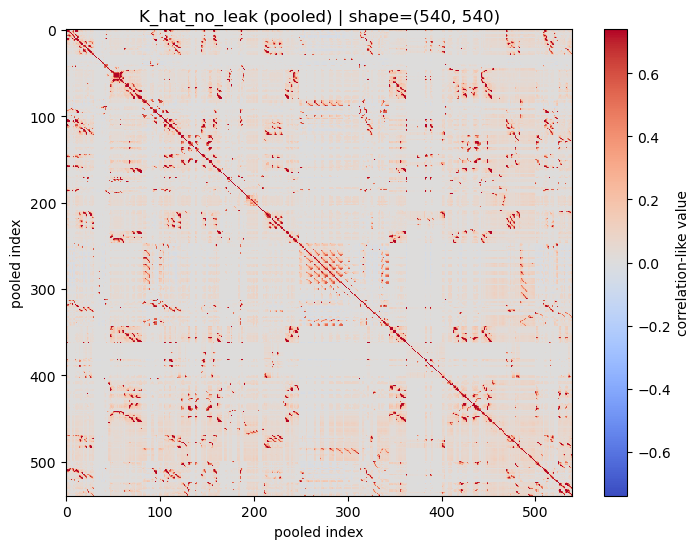

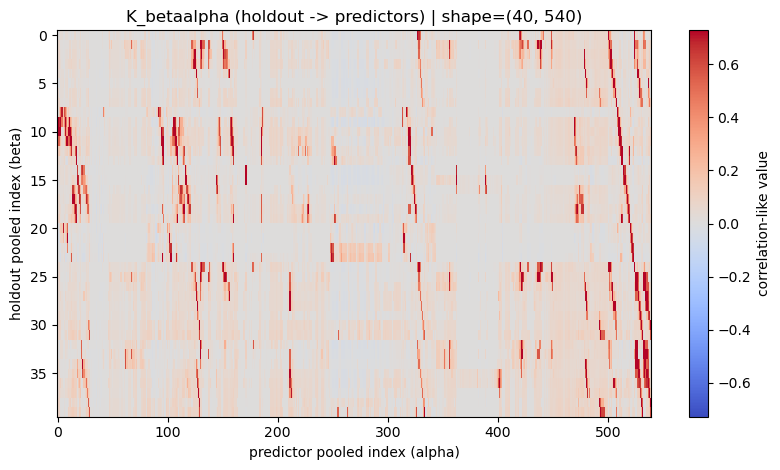

In [500]:
# Correlation-matrix visual check (separate plots)
# 1) K_hat_no_leak: pooled group matrix from training subjects
# 2) K_betaalpha: holdout-to-predictor block used by the decoder

K_betaalpha_view = K_hat_no_leak[np.ix_(beta_pooled_idx, alpha_pooled_idx)]
K_betaalpha_view = np.nan_to_num(K_betaalpha_view, nan=0.0, posinf=0.0, neginf=0.0)


# Plot 1: full pooled matrix
k_lim = np.percentile(np.abs(K_hat_no_leak), 99)
k_lim = max(float(k_lim), 1e-6)

plt.figure(figsize=(7.2, 5.6))
im0 = plt.imshow(K_hat_no_leak, aspect='auto', cmap='coolwarm', vmin=-k_lim, vmax=k_lim, interpolation='nearest')
plt.title(f'K_hat_no_leak (pooled) | shape={K_hat_no_leak.shape}')
plt.xlabel('pooled index')
plt.ylabel('pooled index')
plt.colorbar(im0, label='correlation-like value')
plt.tight_layout()
plt.show()

# Plot 2: holdout-to-predictor block
b_lim = np.percentile(np.abs(K_betaalpha_view), 99)
b_lim = max(float(b_lim), 1e-6)

plt.figure(figsize=(8.2, 4.8))
im1 = plt.imshow(K_betaalpha_view, aspect='auto', cmap='coolwarm', vmin=-b_lim, vmax=b_lim, interpolation='nearest')
plt.title(f'K_betaalpha (holdout -> predictors) | shape={K_betaalpha_view.shape}')
plt.xlabel('predictor pooled index (alpha)')
plt.ylabel('holdout pooled index (beta)')
plt.colorbar(im1, label='correlation-like value')
plt.tight_layout()
plt.show()


## Step 5.1 - Build Decoder and Predict Holdout


In [501]:
K_alphaalpha = K_hat_no_leak[np.ix_(alpha_pooled_idx, alpha_pooled_idx)]
K_betaalpha = K_hat_no_leak[np.ix_(beta_pooled_idx, alpha_pooled_idx)]

K_alphaalpha = np.nan_to_num(K_alphaalpha, nan=0.0, posinf=0.0, neginf=0.0)
K_betaalpha = np.nan_to_num(K_betaalpha, nan=0.0, posinf=0.0, neginf=0.0)

K_alphaalpha_sym = 0.5 * (K_alphaalpha + K_alphaalpha.T)
eigs = np.linalg.eigvalsh(K_alphaalpha_sym)
print('K_alphaalpha eig min/max:', float(eigs.min()), float(eigs.max()))
print('negative eigenvalues:', int((eigs < 0).sum()))


vals, vecs = np.linalg.eigh(K_alphaalpha_sym)
vals = np.clip(vals, 1e-6, None)
K_alphaalpha_psd = (vecs * vals) @ vecs.T
K_alphaalpha_reg = K_alphaalpha_psd + ridge * np.eye(K_alphaalpha_psd.shape[0], dtype=K_alphaalpha_psd.dtype)
D = K_betaalpha @ np.linalg.pinv(K_alphaalpha_reg, rcond=1e-6)
D = np.nan_to_num(D, nan=0.0, posinf=0.0, neginf=0.0)

Y_beta_pred = (D @ Y_alpha.T).T
Y_beta_pred = np.nan_to_num(Y_beta_pred, nan=0.0, posinf=0.0, neginf=0.0)

print('D shape:', D.shape)
print('Y_beta_pred shape:', Y_beta_pred.shape)
print('Finite Y_beta_pred:', np.isfinite(Y_beta_pred).all())



K_alphaalpha eig min/max: -4.606638431549072 34.5942497253418
negative eigenvalues: 152
D shape: (40, 540)
Y_beta_pred shape: (401, 40)
Finite Y_beta_pred: True


## Step 5.2 - Metrics


In [502]:
per_elec_r = np.array([safe_corr(Y_beta_true[:, j], Y_beta_pred[:, j]) for j in range(Y_beta_true.shape[1])], dtype=np.float32)
per_elec_mse = np.mean((Y_beta_true - Y_beta_pred) ** 2, axis=0).astype(np.float32)

valid_r = per_elec_r[np.isfinite(per_elec_r)]
flat_r = safe_corr(Y_beta_true.ravel(), Y_beta_pred.ravel())

if valid_r.size:
    mean_r = float(np.nanmean(valid_r))
    median_r = float(np.nanmedian(valid_r))
else:
    mean_r = np.nan
    median_r = np.nan

print('Aggregate metrics')
print(f'  flat Pearson r:       {flat_r:.4f}')
print(f'  mean per-electrode r: {mean_r:.4f}')
print(f'  median per-electrode: {median_r:.4f}')
print(f'  mean MSE:             {float(np.mean(per_elec_mse)):.4f}')

order = np.argsort(np.nan_to_num(per_elec_r, nan=-np.inf))[::-1]
print('\nTop 10 electrodes by r')
for rank, j in enumerate(order[:10], start=1):
    print(f'  top {rank:02d}: holdout elec {j:02d} | pooled {int(beta_pooled_idx[j]):04d} | r={per_elec_r[j]:.4f} | mse={per_elec_mse[j]:.4f}')


Aggregate metrics
  flat Pearson r:       0.0236
  mean per-electrode r: 0.0186
  median per-electrode: 0.0286
  mean MSE:             1.1462

Top 10 electrodes by r
  top 01: holdout elec 10 | pooled 0510 | r=0.1058 | mse=1.0784
  top 02: holdout elec 23 | pooled 0523 | r=0.1023 | mse=1.0843
  top 03: holdout elec 36 | pooled 0536 | r=0.0952 | mse=1.2570
  top 04: holdout elec 09 | pooled 0509 | r=0.0931 | mse=1.0695
  top 05: holdout elec 37 | pooled 0537 | r=0.0909 | mse=1.0936
  top 06: holdout elec 28 | pooled 0528 | r=0.0831 | mse=1.1566
  top 07: holdout elec 25 | pooled 0525 | r=0.0750 | mse=1.0961
  top 08: holdout elec 22 | pooled 0522 | r=0.0716 | mse=1.1270
  top 09: holdout elec 12 | pooled 0512 | r=0.0669 | mse=1.0885
  top 10: holdout elec 34 | pooled 0534 | r=0.0663 | mse=1.0853


## Step 5.3 - Quick Plots


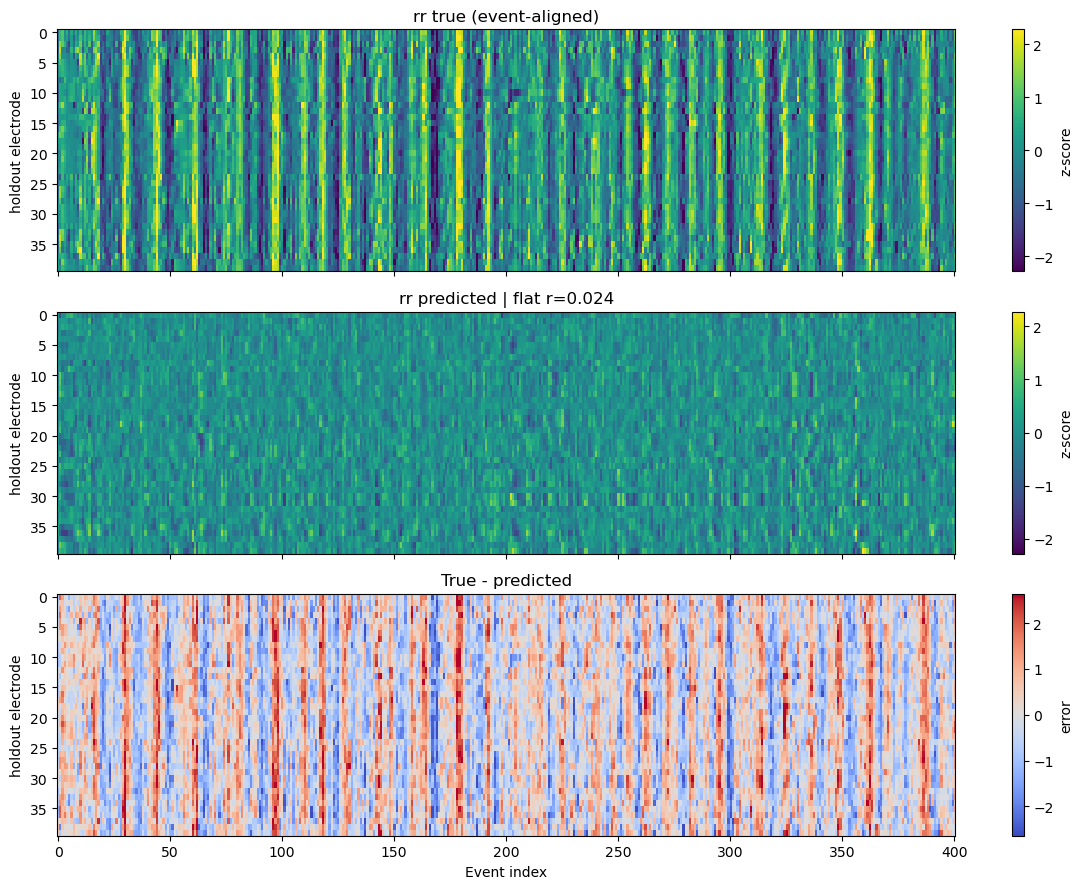

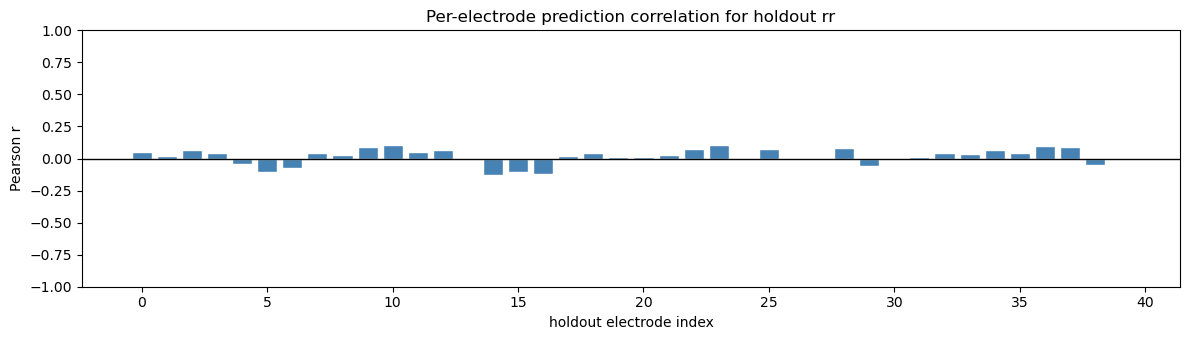

In [503]:
# Heatmaps over event index
true_ds = Y_beta_true
pred_ds = Y_beta_pred
err_ds = true_ds - pred_ds

vlim = np.percentile(np.abs(np.r_[true_ds.ravel(), pred_ds.ravel()]), 99)
vlim = max(float(vlim), 1e-6)
err_lim = np.percentile(np.abs(err_ds.ravel()), 99)
err_lim = max(float(err_lim), 1e-6)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

im0 = axes[0].imshow(true_ds.T, aspect='auto', cmap='viridis', vmin=-vlim, vmax=vlim, interpolation='nearest')
axes[0].set_title(f'{holdout_pid} true (event-aligned)')
axes[0].set_ylabel('holdout electrode')
fig.colorbar(im0, ax=axes[0], label='z-score')

im1 = axes[1].imshow(pred_ds.T, aspect='auto', cmap='viridis', vmin=-vlim, vmax=vlim, interpolation='nearest')
axes[1].set_title(f'{holdout_pid} predicted | flat r={flat_r:.3f}')
axes[1].set_ylabel('holdout electrode')
fig.colorbar(im1, ax=axes[1], label='z-score')

im2 = axes[2].imshow(err_ds.T, aspect='auto', cmap='coolwarm', vmin=-err_lim, vmax=err_lim, interpolation='nearest')
axes[2].set_title('True - predicted')
axes[2].set_ylabel('holdout electrode')
axes[2].set_xlabel('Event index')
fig.colorbar(im2, ax=axes[2], label='error')

plt.tight_layout()
plt.show()

# Bar chart of per-electrode r
plt.figure(figsize=(12, 3.5))
plt.bar(np.arange(per_elec_r.size), per_elec_r, color='steelblue', edgecolor='white')
plt.axhline(0.0, color='black', linewidth=1)
plt.ylim(-1.0, 1.0)
plt.xlabel('holdout electrode index')
plt.ylabel('Pearson r')
plt.title(f'Per-electrode prediction correlation for holdout {holdout_pid}')
plt.tight_layout()
plt.show()


## Notes

- If `holdout_pid='aa'` and `include_rr_in_training=True`, the notebook uses `n_events_common=401` so `rr` is included fairly.
- If `holdout_pid='rr'`, this naturally evaluates on the first 401 events (since `rr` is shortest).
- Holding out `rr` is not more complicated; it is often simpler because the common event count is automatically 401.


## Step 5.4 - Random Electrode Traces (First 100 Points)

Note: this notebook is event-aligned, so x-axis here is event index (not milliseconds).


Selected holdout electrode indices: [10, 19, 24, 31]
Showing first 100 event points


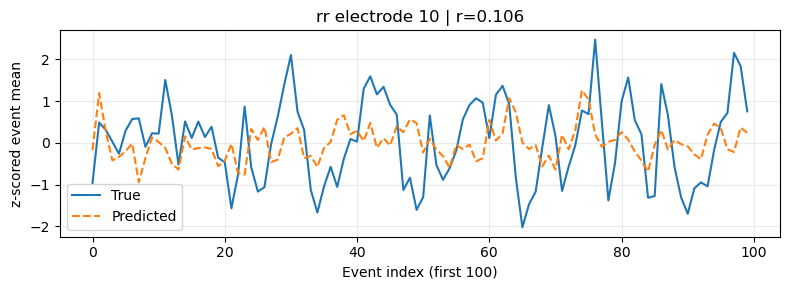

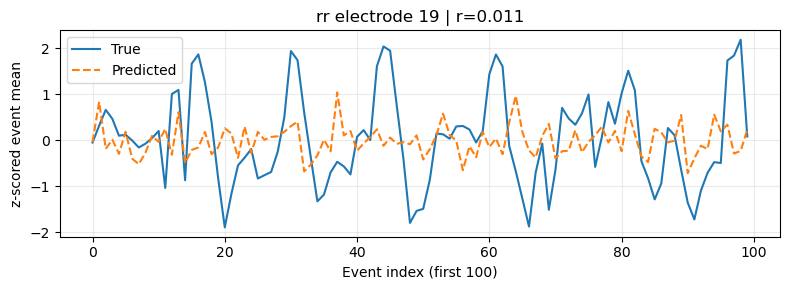

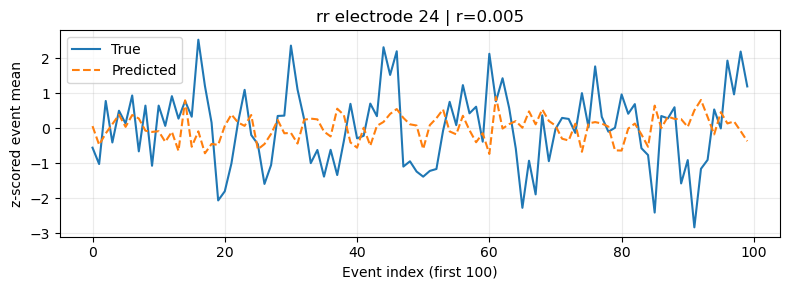

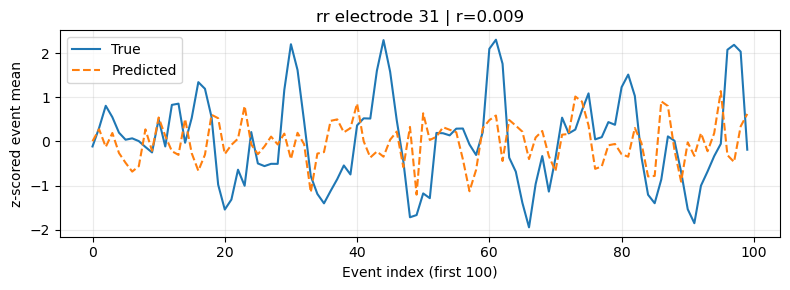

In [504]:
# Plot a few random holdout electrodes: true vs predicted (first 100 event points)
rng = np.random.default_rng(0)
n_show = min(4, Y_beta_true.shape[1])
sel = np.sort(rng.choice(Y_beta_true.shape[1], size=n_show, replace=False))

n_show_pts = min(100, Y_beta_true.shape[0])
x = np.arange(n_show_pts)

print('Selected holdout electrode indices:', sel.tolist())
print('Showing first', n_show_pts, 'event points')

for j in sel:
    plt.figure(figsize=(8, 3))
    plt.plot(x, Y_beta_true[:n_show_pts, j], label='True', linewidth=1.5)
    plt.plot(x, Y_beta_pred[:n_show_pts, j], label='Predicted', linewidth=1.5, linestyle='--')
    rj = safe_corr(Y_beta_true[:, j], Y_beta_pred[:, j])
    plt.title(f'{holdout_pid} electrode {j} | r={rj:.3f}')
    plt.xlabel('Event index (first 100)')
    plt.ylabel('z-scored event mean')
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()
